(312, 17)
['formula', 'c', 'mn', 'si', 'cr', 'ni', 'mo', 'v', 'n', 'nb', 'co', 'w', 'al', 'ti', 'yield strength', 'tensile strength', 'elongation']
                                             formula     c    mn    si     cr  \
0  Fe0.620C0.000953Mn0.000521Si0.00102Cr0.000110N...  0.02  0.05  0.05   0.01   
1  Fe0.623C0.00854Mn0.000104Si0.000203Cr0.147Ni0....  0.18  0.01  0.01  13.44   
2  Fe0.625Mn0.000102Si0.000200Cr0.0936Ni0.129Mo0....  0.00  0.01  0.01   8.67   
3  Fe0.634C0.000478Mn0.000523Si0.00102Cr0.000111N...  0.01  0.05  0.05   0.01   
4  Fe0.636C0.000474Mn0.000518Si0.00101Cr0.000109N...  0.01  0.05  0.05   0.01   

      ni    mo     v     n    nb     co     w    al    ti  yield strength  \
0  19.70  2.95  0.01  0.00  0.01  15.00  0.00  0.15  1.55          2411.5   
1   0.01  3.01  0.46  0.04  0.01  19.46  2.35  0.04  0.00          1123.1   
2  13.45  0.82  0.01  0.00  0.01  13.90  0.00  0.39  0.57          1736.3   
3  17.70  3.95  0.01  0.00  0.01  15.00  0.00  0.13  1.47

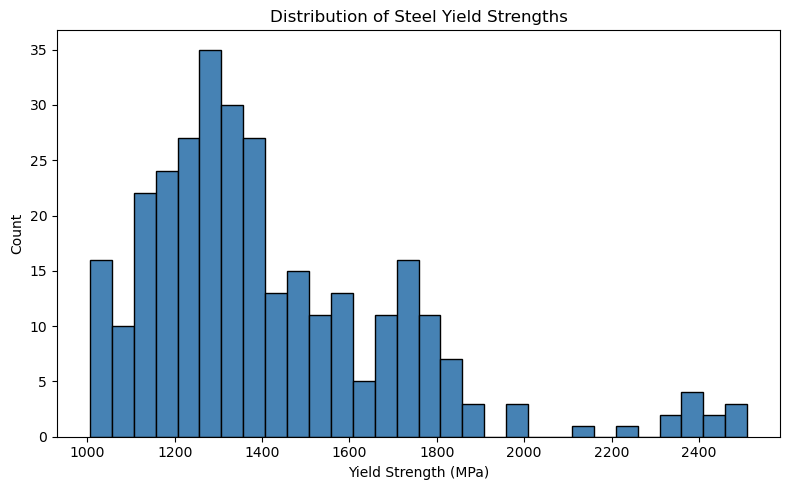

In [2]:
from matminer.datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
 
df = load_dataset("steel_strength")
print(df.shape)
print(df.columns.tolist())
df.head()

print(df.head())
print("\nBasic statistics:")
print(df['yield strength'].describe())

plt.figure(figsize=(8, 5))
plt.hist(df['yield strength'], bins=30, color='steelblue', edgecolor='black')
plt.xlabel('Yield Strength (MPa)')
plt.ylabel('Count')
plt.title('Distribution of Steel Yield Strengths')
plt.tight_layout()
plt.show()

In [3]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

feature_cols = ['c', 'mn', 'si', 'cr', 'ni', 'mo', 'v', 'n', 'nb', 'co', 'w', 'al', 'ti']
X = df[feature_cols]
y = df['yield strength']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
print(f"Random Forest RMSE: {rf_rmse:.1f} MPa")

Random Forest RMSE: 120.3 MPa


In [1]:
import tensorflow as tf
from sklearn.preprocessing import StandardScaler

# Scaling features for best results with neural networks
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

nn_model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

nn_model.compile(optimizer='adam', loss='mse')
nn_model.fit(X_train_scaled, y_train, epochs=100, verbose=0)

nn_predictions = nn_model.predict(X_test_scaled).flatten()
nn_rmse = np.sqrt(mean_squared_error(y_test, nn_predictions))
print(f"Neural Network RMSE: {nn_rmse:.1f} MPa")

: 